In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [10]:
image = cv2.imread("fotodiri.jpeg")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Ukuran gambar :", image.shape)

Ukuran gambar : (1600, 1200, 3)


In [11]:
median = cv2.medianBlur(image_rgb, 5)

In [12]:
def mean_filter_manual(img, kernel_size=3):

    padding = kernel_size // 2

    # Ubah ke int32 agar tidak overflow
    padded = np.pad(
        img.astype(np.int32),
        ((padding, padding),
         (padding, padding),
         (0, 0)),
        mode='edge'
    )

    output = np.zeros(img.shape, dtype=np.uint8)

    tinggi, lebar, channel = img.shape

    for y in range(tinggi):
        for x in range(lebar):
            for c in range(channel):

                total = 0

                for ky in range(kernel_size):
                    for kx in range(kernel_size):
                        total += padded[y+ky, x+kx, c]

                rata = total // (kernel_size * kernel_size)

                output[y, x, c] = np.clip(rata, 0, 255)

    return output

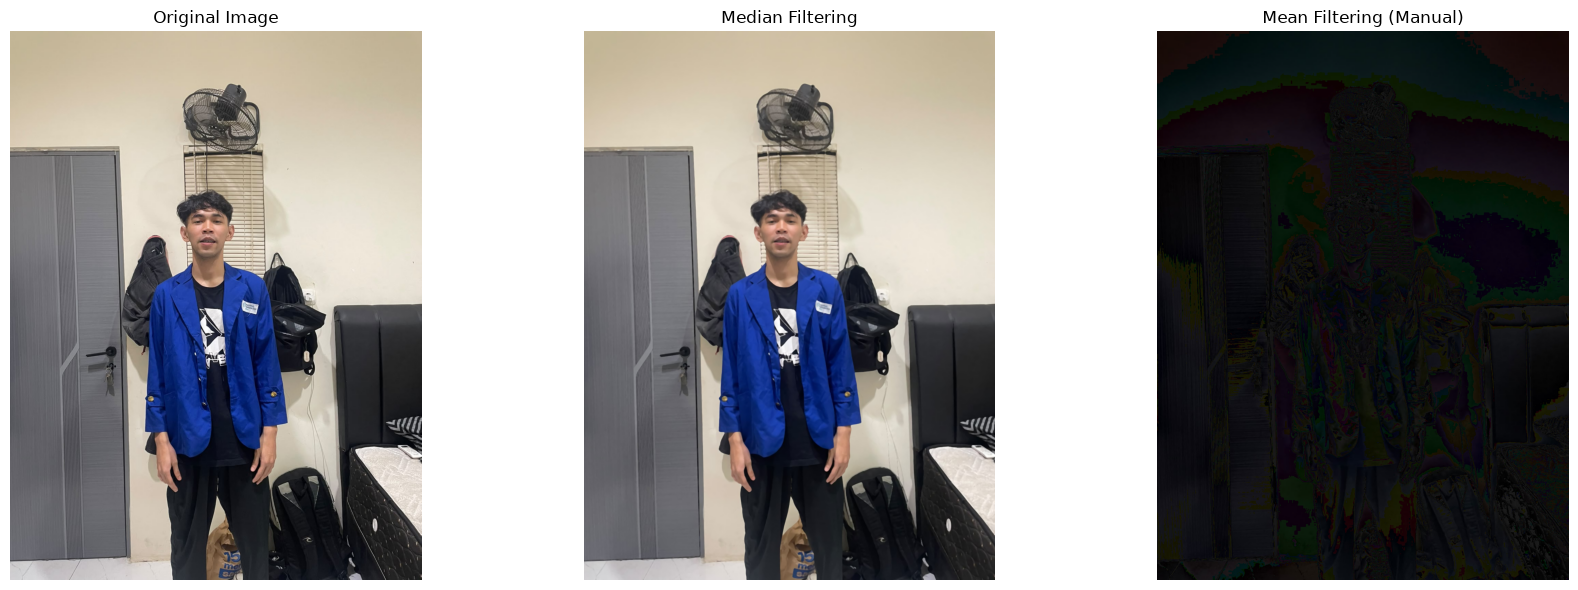

In [13]:
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(median)
plt.title("Median Filtering")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(mean)
plt.title("Mean Filtering (Manual)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
hasil = np.hstack((image_rgb, median, mean))

hasil = cv2.cvtColor(hasil, cv2.COLOR_RGB2BGR)

cv2.imwrite("hasil_output.png", hasil)

print("Hasil berhasil disimpan.")

Hasil berhasil disimpan.
